# Laboratorio: MLPs, verosimilitud, entrenamiento y evaluación

**Nombre:** Michaelle Perez  
**Institución:** BioMedLab Galileo - deeplearning.ai  

Este laboratorio acompaña la sesión sobre perceptrones multicapa. El objetivo es practicar el flujo completo:

1. creación y carga de datasets;
2. visualización;
3. normalización y estandarización;
4. construcción de redes MLP;
5. entrenamiento;
6. evaluación con métricas apropiadas;
7. pruebas públicas y privadas.

Las notas de clase proveen el desarrollo teórico completo. Este notebook se enfoca en ejemplos computacionales y tareas implementables.

> Importante: en las celdas Markdown se usa `$$...$$` para bloques de LaTeX.


## Identificación del estudiante

Antes de ejecutar pruebas privadas, cambie los valores de `ID` y `NOMBRE`.


In [1]:
ID = "20032276"
NOMBRE = "Eduardo Pivaral Leal"


## Imports

Este laboratorio usa `numpy`, `pandas`, `matplotlib`, `scikit-learn` y `torch`.


In [ ]:
%pip install torch

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_multilabel_classification
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print("PyTorch:", torch.__version__)
print("Data directory:", DATA_DIR.resolve())


PyTorch: 2.13.0
Data directory: /Users/macbook/Library/CloudStorage/OneDrive-Personal/Documents/Tareas Galileo/IA/Procesamiento de imagenes y CV/lab1/data


# 1. Creación de datasets

Se crearán cuatro datasets con 1,000 ejemplos para entrenamiento y 200 para desarrollo.

| Dataset | Tipo | Entradas | Salida |
|---|---|---:|---|
| A | Clasificación binaria | 2 features | 1 etiqueta binaria |
| B | Regresión no lineal de orden 5 | 2 features | 1 valor continuo |
| C | Clasificación multiclase | 2 features | 4 clases |
| D | Clasificación multilabel | 2 features | 4 etiquetas binarias |

Los datasets se guardan como CSV para luego cargarlos desde archivo, simulando un flujo real de trabajo.


In [3]:
rng = np.random.default_rng(42)

# Dataset A: clasificación binaria, 2 features
XA, yA = make_classification(
    n_samples=1200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    class_sep=1.35,
    flip_y=0.03,
    random_state=11,
)

XA_train, XA_dev, yA_train, yA_dev = train_test_split(
    XA, yA,
    train_size=1000,
    test_size=200,
    stratify=yA,
    random_state=101,
)

# Dataset B: regresión no lineal de orden 5, 2 features
XB = rng.uniform(-1.6, 1.6, size=(1200, 2))
x1, x2 = XB[:, 0], XB[:, 1]
noise = rng.normal(0, 0.35, size=1200)

yB = (
    0.55 * x1**5
    - 0.45 * x2**5
    + 0.80 * x1**3
    - 0.65 * x2**2
    + 0.50 * x1**2 * x2
    - 0.35 * x1 * x2**3
    + 0.25 * x1
    + noise
)

XB_train, XB_dev, yB_train, yB_dev = train_test_split(
    XB, yB,
    train_size=1000,
    test_size=200,
    random_state=202,
)

# Dataset C: clasificación multiclase con 4 clases, 2 features
XC, yC = make_classification(
    n_samples=1200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=4,
    n_clusters_per_class=1,
    class_sep=1.45,
    flip_y=0.04,
    random_state=33,
)

XC_train, XC_dev, yC_train, yC_dev = train_test_split(
    XC, yC,
    train_size=1000,
    test_size=200,
    stratify=yC,
    random_state=303,
)

# Dataset D: clasificación multilabel con 4 clases, 2 features
XD, yD = make_multilabel_classification(
    n_samples=1200,
    n_features=2,
    n_classes=4,
    n_labels=2,
    allow_unlabeled=False,
    random_state=44,
)

XD = XD.astype(np.float64) + rng.normal(0, 0.05, size=XD.shape)
strat_D = yD.sum(axis=1)

XD_train, XD_dev, yD_train, yD_dev = train_test_split(
    XD, yD,
    train_size=1000,
    test_size=200,
    stratify=strat_D,
    random_state=404,
)

def save_csv(prefix, X_train, X_dev, y_train, y_dev, multilabel=False):
    if multilabel:
        train_df = pd.DataFrame(X_train, columns=["x1", "x2"])
        dev_df = pd.DataFrame(X_dev, columns=["x1", "x2"])
        for k in range(y_train.shape[1]):
            train_df[f"y{k}"] = y_train[:, k].astype(int)
            dev_df[f"y{k}"] = y_dev[:, k].astype(int)
    else:
        train_df = pd.DataFrame(X_train, columns=["x1", "x2"])
        dev_df = pd.DataFrame(X_dev, columns=["x1", "x2"])
        train_df["y"] = y_train
        dev_df["y"] = y_dev

    train_df.to_csv(DATA_DIR / f"dataset_{prefix}_train.csv", index=False)
    dev_df.to_csv(DATA_DIR / f"dataset_{prefix}_dev.csv", index=False)

save_csv("A", XA_train, XA_dev, yA_train, yA_dev)
save_csv("B", XB_train, XB_dev, yB_train, yB_dev)
save_csv("C", XC_train, XC_dev, yC_train, yC_dev)
save_csv("D", XD_train, XD_dev, yD_train, yD_dev, multilabel=True)

for path in sorted(DATA_DIR.glob("*.csv")):
    print(path, pd.read_csv(path).shape)


data/dataset_A_dev.csv (200, 3)
data/dataset_A_train.csv (1000, 3)
data/dataset_B_dev.csv (200, 3)
data/dataset_B_train.csv (1000, 3)
data/dataset_C_dev.csv (200, 3)
data/dataset_C_train.csv (1000, 3)
data/dataset_D_dev.csv (200, 6)
data/dataset_D_train.csv (1000, 6)


# 2. Verosimilitud, máxima verosimilitud y KL divergence

La verosimilitud interpreta la probabilidad de los datos observados como una función de los parámetros.

Si tenemos datos:

$$
\mathcal{D}=\{x_i\}_{i=1}^{N}
$$

y un modelo paramétrico:

$$
p(x;\theta)
$$

la verosimilitud es:

$$
L(\theta)=p(\mathcal{D};\theta)
$$

Si los datos son independientes:

$$
L(\theta)=\prod_{i=1}^{N}p(x_i;\theta)
$$

La log-verosimilitud es:

$$
\ell(\theta)=\sum_{i=1}^{N}\log p(x_i;\theta)
$$

El estimador de máxima verosimilitud busca:

$$
\hat{\theta}_{MLE}=\arg\max_{\theta}\ell(\theta)
$$

En el ejemplo siguiente se genera una muestra desde una distribución Bernoulli con parámetro verdadero \(p^\star\). Luego se evalúan varios valores candidatos de \(p\). La log-verosimilitud se maximiza cerca del parámetro empírico de la muestra. La divergencia KL entre la distribución empírica y la distribución candidata se minimiza en el mismo punto.

La KL divergence entre dos Bernoulli \(q\) y \(p\) es:

$$
D_{KL}(q||p)=q\log\frac{q}{p}+(1-q)\log\frac{1-q}{1-p}
$$

Importante: la KL no se maximiza en los parámetros verdaderos. La KL se minimiza cuando ambas distribuciones coinciden.


p verdadero: 0.72
p empírico: 0.722
p que maximiza log-verosimilitud en la grilla: 0.724070351758794
p que minimiza KL en la grilla: 0.724070351758794


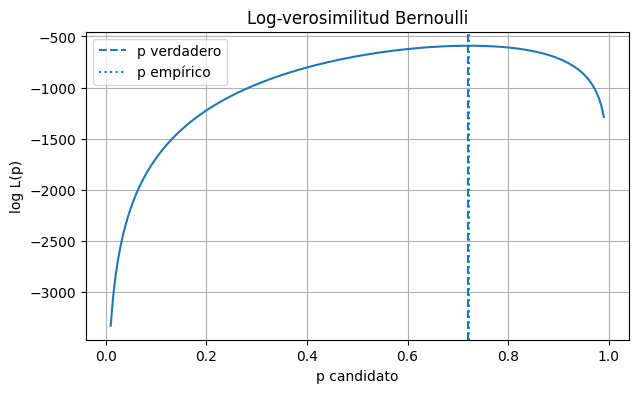

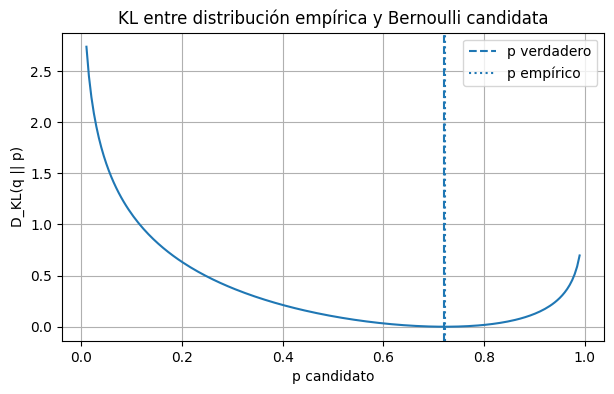

In [4]:
rng = np.random.default_rng(123)

p_true = 0.72
n = 1000
sample = rng.binomial(n=1, p=p_true, size=n)

p_empirical = sample.mean()
grid = np.linspace(0.01, 0.99, 200)

def bernoulli_log_likelihood(sample, p):
    return np.sum(sample * np.log(p) + (1 - sample) * np.log(1 - p))

def kl_bernoulli(q, p):
    return q * np.log(q / p) + (1 - q) * np.log((1 - q) / (1 - p))

log_likelihoods = np.array([bernoulli_log_likelihood(sample, p) for p in grid])
kl_values = np.array([kl_bernoulli(p_empirical, p) for p in grid])

p_mle_grid = grid[np.argmax(log_likelihoods)]
p_kl_min_grid = grid[np.argmin(kl_values)]

print("p verdadero:", p_true)
print("p empírico:", p_empirical)
print("p que maximiza log-verosimilitud en la grilla:", p_mle_grid)
print("p que minimiza KL en la grilla:", p_kl_min_grid)

plt.figure(figsize=(7, 4))
plt.plot(grid, log_likelihoods)
plt.axvline(p_true, linestyle="--", label="p verdadero")
plt.axvline(p_empirical, linestyle=":", label="p empírico")
plt.title("Log-verosimilitud Bernoulli")
plt.xlabel("p candidato")
plt.ylabel("log L(p)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(grid, kl_values)
plt.axvline(p_true, linestyle="--", label="p verdadero")
plt.axvline(p_empirical, linestyle=":", label="p empírico")
plt.title("KL entre distribución empírica y Bernoulli candidata")
plt.xlabel("p candidato")
plt.ylabel("D_KL(q || p)")
plt.legend()
plt.grid(True)
plt.show()


# 3. Funciones auxiliares de preprocesamiento

En este laboratorio se pide practicar dos transformaciones:

1. **Normalización min-max sobre todo el dataset**: se ajusta con train + dev.
2. **Estandarización sobre train normalizado**: la media y desviación se ajustan solo sobre train normalizado y luego se aplican a dev.

La normalización min-max es:

$$
x'=\frac{x-x_{min}}{x_{max}-x_{min}}
$$

La estandarización es:

$$
z=\frac{x'-\mu_{train}}{\sigma_{train}}
$$

En proyectos reales, usualmente se evita ajustar cualquier transformación con dev o test. Aquí se pide explícitamente normalizar sobre todo el dataset para fines didácticos y luego estandarizar usando solo train.


In [5]:
def normalize_all_then_standardize_train(train_df, dev_df, feature_cols=("x1", "x2")):
    X_train = train_df[list(feature_cols)].to_numpy(dtype=np.float32)
    X_dev = dev_df[list(feature_cols)].to_numpy(dtype=np.float32)

    all_X = np.vstack([X_train, X_dev])
    normalizer = MinMaxScaler()
    normalizer.fit(all_X)

    X_train_norm = normalizer.transform(X_train)
    X_dev_norm = normalizer.transform(X_dev)

    standardizer = StandardScaler()
    standardizer.fit(X_train_norm)

    X_train_std = standardizer.transform(X_train_norm).astype(np.float32)
    X_dev_std = standardizer.transform(X_dev_norm).astype(np.float32)

    return X_train_std, X_dev_std, normalizer, standardizer


def make_loader(X, y, batch_size=64, shuffle=True):
    X_tensor = torch.tensor(X, dtype=torch.float32)

    if y.dtype.kind in {"i", "u"}:
        y_tensor = torch.tensor(y, dtype=torch.long)
    else:
        y_tensor = torch.tensor(y, dtype=torch.float32)

    ds = TensorDataset(X_tensor, y_tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


# 4. Ejemplo completo: Dataset A, clasificación binaria

En este ejemplo se implementa el flujo completo para clasificación binaria:

1. visualizar el dataset;
2. preprocesar las entradas;
3. crear una red neuronal de 3 capas lineales: \(2 \rightarrow 8 \rightarrow 8 \rightarrow 1\);
4. entrenar la red;
5. medir métricas apropiadas en dev.

Para clasificación binaria usamos un logit de salida y `BCEWithLogitsLoss`.

La probabilidad se obtiene después con:

$$
\hat{p}=\sigma(z)
$$

donde \(z\) es el logit.


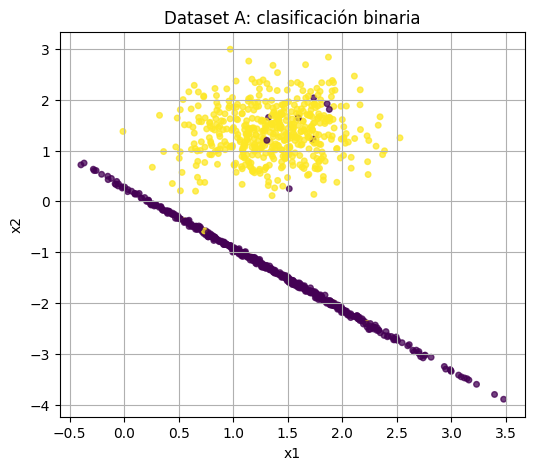

In [6]:
A_train = pd.read_csv(DATA_DIR / "dataset_A_train.csv")
A_dev = pd.read_csv(DATA_DIR / "dataset_A_dev.csv")

plt.figure(figsize=(6, 5))
plt.scatter(A_train["x1"], A_train["x2"], c=A_train["y"], s=16, alpha=0.75)
plt.title("Dataset A: clasificación binaria")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

X_A_train, X_A_dev, norm_A, std_A = normalize_all_then_standardize_train(A_train, A_dev)
y_A_train = A_train["y"].to_numpy(dtype=np.float32).reshape(-1, 1)
y_A_dev = A_dev["y"].to_numpy(dtype=np.float32).reshape(-1, 1)

train_A_loader = DataLoader(
    TensorDataset(torch.tensor(X_A_train), torch.tensor(y_A_train)),
    batch_size=64,
    shuffle=True,
)
dev_A_loader = DataLoader(
    TensorDataset(torch.tensor(X_A_dev), torch.tensor(y_A_dev)),
    batch_size=256,
    shuffle=False,
)


{'accuracy': 0.98, 'precision': 0.9702970297029703, 'recall': 0.98989898989899, 'f1': 0.98, 'confusion_matrix': array([[98,  3],
       [ 1, 98]])}


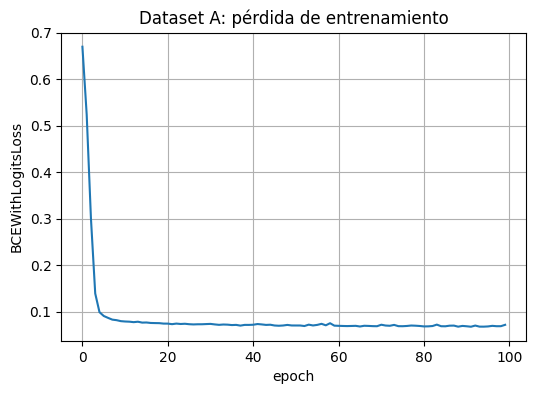

In [7]:
class BinaryMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=8, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)


def train_binary_model(model, train_loader, epochs=100, lr=1e-2):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_n = 0

        for xb, yb in train_loader:
            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_n += xb.size(0)

        history.append(total_loss / total_n)

    return history


def evaluate_binary_model(model, dev_loader, threshold=0.5):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for xb, yb in dev_loader:
            logits = model(xb)
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).int()

            y_true.append(yb.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    y_true = np.vstack(y_true).reshape(-1)
    y_pred = np.vstack(y_pred).reshape(-1)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }


binary_model = BinaryMLP()
history_A = train_binary_model(binary_model, train_A_loader, epochs=100, lr=1e-2)
metrics_A = evaluate_binary_model(binary_model, dev_A_loader)

print(metrics_A)

plt.figure(figsize=(6, 4))
plt.plot(history_A)
plt.title("Dataset A: pérdida de entrenamiento")
plt.xlabel("epoch")
plt.ylabel("BCEWithLogitsLoss")
plt.grid(True)
plt.show()


# 5. Pruebas públicas y privadas

Las pruebas públicas se ejecutan dentro del notebook para dar retroalimentación al estudiante.

La calificación final se distribuye así:

| Tarea | Dataset | Peso |
|---|---|---:|
| Tarea 1 | Dataset B, regresión | 30% |
| Tarea 2 | Dataset C, multiclase | 30% |
| Tarea 3 | Dataset D, multilabel | 40% |

Dentro de cada tarea:

| Subtarea | Peso interno |
|---|---:|
| Modelo MLP | 40% |
| Función de entrenamiento | 30% |
| Función de evaluación | 30% |


# Tarea 1 — Dataset B: regresión no lineal

Esta tarea utiliza el dataset B.

## Actividades no calificadas

1. Visualizar el dataset B.
2. Normalizar las entradas sobre todo el dataset.
3. Estandarizar las entradas usando las estadísticas de train normalizado.

## Actividades calificadas

Debe implementar:

1. `RegressionMLP`: red MLP para regresión con arquitectura \(2 \rightarrow 8 \rightarrow 8 \rightarrow 1\), ReLU en las capas ocultas y salida lineal.
2. `train_regression_model`: función que entrena la red durante 100 epochs por defecto.
3. `evaluate_regression_model`: función que retorna métricas apropiadas.

Métricas esperadas:

- `mse`;
- `rmse`;
- `mae`;
- `r2`.

Para regresión con error normal, MSE corresponde a la log-verosimilitud negativa, salvo constantes y escala:

$$
\mathcal{L}_{MSE}
=
\frac{1}{N}
\sum_{i=1}^{N}
(y_i-\hat{y}_i)^2
$$


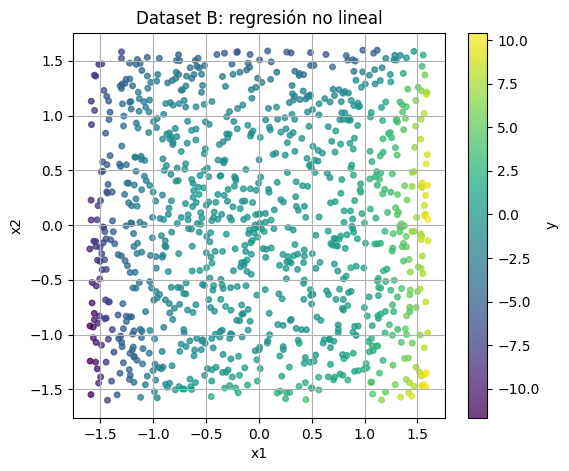

X_B_train: (1000, 2)
y_B_train: (1000, 1)


In [8]:
B_train = pd.read_csv(DATA_DIR / "dataset_B_train.csv")
B_dev = pd.read_csv(DATA_DIR / "dataset_B_dev.csv")

# Non-graded: visualización
plt.figure(figsize=(6, 5))
plt.scatter(B_train["x1"], B_train["x2"], c=B_train["y"], s=16, alpha=0.75)
plt.title("Dataset B: regresión no lineal")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="y")
plt.grid(True)
plt.show()

# Non-graded: normalización y estandarización
X_B_train, X_B_dev, norm_B, std_B = normalize_all_then_standardize_train(B_train, B_dev)
y_B_train = B_train["y"].to_numpy(dtype=np.float32).reshape(-1, 1)
y_B_dev = B_dev["y"].to_numpy(dtype=np.float32).reshape(-1, 1)

train_B_loader = DataLoader(
    TensorDataset(torch.tensor(X_B_train), torch.tensor(y_B_train)),
    batch_size=64,
    shuffle=True,
)
dev_B_loader = DataLoader(
    TensorDataset(torch.tensor(X_B_dev), torch.tensor(y_B_dev)),
    batch_size=256,
    shuffle=False,
)

print("X_B_train:", X_B_train.shape)
print("y_B_train:", y_B_train.shape)


In [9]:
# GRADED: Tarea 1

class RegressionMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=8, output_dim=1):
        super().__init__()

        # START CODE HERE
        #raise NotImplementedError("Implemente la arquitectura 2 -> 8 -> 8 -> 1 con ReLU.")
        self.net = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, output_dim),
        )
        # END CODE HERE

    def forward(self, x):
        # START CODE HERE
        #raise NotImplementedError("Implemente el forward pass.")
        return self.net(x)

        # END CODE HERE


def train_regression_model(model, train_loader, epochs=100, lr=1e-2):
    """
    Entrena un modelo de regresión usando MSELoss.

    Debe retornar una lista con la pérdida promedio por epoch.
    """
    # START CODE HERE
    #raise NotImplementedError("Implemente el loop de entrenamiento para regresión.")

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_n = 0

        for xb, yb in train_loader:
            predictions = model(xb)
            loss = criterion(predictions, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_n += xb.size(0)

        history.append(total_loss / total_n)

    return history
    

    # END CODE HERE


def evaluate_regression_model(model, dev_loader):
    """
    Evalúa el modelo de regresión.

    Debe retornar un diccionario con:
        mse, rmse, mae, r2
    """
    # START CODE HERE
    #raise NotImplementedError("Implemente las métricas de regresión.")

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for xb, yb in dev_loader:
            predictions = model(xb)

            y_true.append(yb.cpu().numpy())
            y_pred.append(predictions.cpu().numpy())

    y_true = np.vstack(y_true).reshape(-1)
    y_pred = np.vstack(y_pred).reshape(-1)

    mse = mean_squared_error(y_true, y_pred)

    return {
        "mse": mse,
        "rmse": np.sqrt(mse),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }
    # END CODE HERE


In [11]:
import public_tests

In [12]:
# Public test: ejecutar después de implementar Tarea 1.
public_tests.test_tarea1(globals())


Tarea 1 public tests passed.


# Tarea 2 — Dataset C: clasificación multiclase

Esta tarea utiliza el dataset C.

## Actividades no calificadas

1. Visualizar el dataset C.
2. Normalizar las entradas sobre todo el dataset.
3. Estandarizar las entradas usando las estadísticas de train normalizado.

## Actividades calificadas

Debe implementar:

1. `MulticlassMLP`: red MLP para clasificación multiclase con arquitectura \(2 \rightarrow 8 \rightarrow 8 \rightarrow 4\), ReLU en las capas ocultas y salida de 4 logits.
2. `train_multiclass_model`: función que entrena la red durante 100 epochs por defecto.
3. `evaluate_multiclass_model`: función que retorna métricas apropiadas.

Métricas esperadas:

- `accuracy`;
- `macro_f1`;
- `confusion_matrix`.

Para clasificación multiclase se usa cross-entropy categórica:

$$
\mathcal{L}_{CE}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\log p(y_i|\mathbf{x}_i)
$$

En PyTorch, `CrossEntropyLoss` recibe logits directamente.


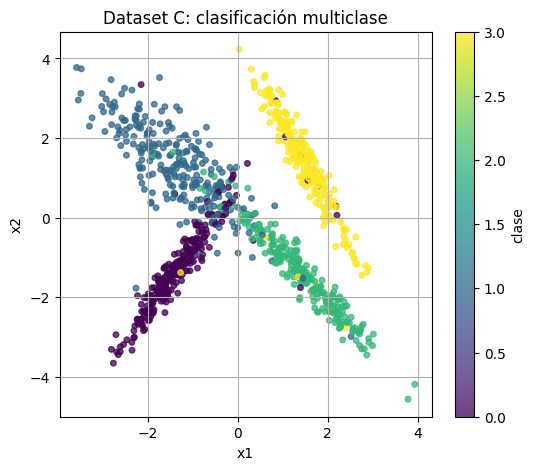

X_C_train: (1000, 2)
y_C_train: (1000,)


In [13]:
C_train = pd.read_csv(DATA_DIR / "dataset_C_train.csv")
C_dev = pd.read_csv(DATA_DIR / "dataset_C_dev.csv")

# Non-graded: visualización
plt.figure(figsize=(6, 5))
plt.scatter(C_train["x1"], C_train["x2"], c=C_train["y"], s=16, alpha=0.75)
plt.title("Dataset C: clasificación multiclase")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="clase")
plt.grid(True)
plt.show()

# Non-graded: normalización y estandarización
X_C_train, X_C_dev, norm_C, std_C = normalize_all_then_standardize_train(C_train, C_dev)
y_C_train = C_train["y"].to_numpy(dtype=np.int64)
y_C_dev = C_dev["y"].to_numpy(dtype=np.int64)

train_C_loader = DataLoader(
    TensorDataset(torch.tensor(X_C_train), torch.tensor(y_C_train)),
    batch_size=64,
    shuffle=True,
)
dev_C_loader = DataLoader(
    TensorDataset(torch.tensor(X_C_dev), torch.tensor(y_C_dev)),
    batch_size=256,
    shuffle=False,
)

print("X_C_train:", X_C_train.shape)
print("y_C_train:", y_C_train.shape)


In [14]:
# GRADED: Tarea 2

class MulticlassMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=8, output_dim=4):
        super().__init__()

        # START CODE HERE
        #raise NotImplementedError("Implemente la arquitectura 2 -> 8 -> 8 -> 4 con ReLU.")

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
        
        # END CODE HERE

    def forward(self, x):
        # START CODE HERE
        #raise NotImplementedError("Implemente el forward pass.")

        return self.net(x)
        # END CODE HERE


def train_multiclass_model(model, train_loader, epochs=100, lr=1e-2):
    """
    Entrena un modelo de clasificación multiclase usando CrossEntropyLoss.

    Debe retornar una lista con la pérdida promedio por epoch.
    """
    # START CODE HERE
    #raise NotImplementedError("Implemente el loop de entrenamiento para clasificación multiclase.")


    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_n = 0

        for xb, yb in train_loader:
            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_n += xb.size(0)

        history.append(total_loss / total_n)

    return history

    # END CODE HERE


def evaluate_multiclass_model(model, dev_loader):
    """
    Evalúa el modelo multiclase.

    Debe retornar un diccionario con:
        accuracy, macro_f1, confusion_matrix
    """
    # START CODE HERE
    #raise NotImplementedError("Implemente las métricas de clasificación multiclase.")

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for xb, yb in dev_loader:
            logits = model(xb)
            predictions = torch.argmax(logits, dim=1)

            y_true.append(yb.cpu().numpy())
            y_pred.append(predictions.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }


    # END CODE HERE


In [15]:
# Public test: ejecutar después de implementar Tarea 2.
public_tests.test_tarea2(globals())


Tarea 2 public tests passed.


# Tarea 3 — Dataset D: clasificación multilabel

Esta tarea utiliza el dataset D.

## Actividades no calificadas

1. Visualizar el dataset D.
2. Normalizar las entradas sobre todo el dataset.
3. Estandarizar las entradas usando las estadísticas de train normalizado.

## Actividades calificadas

Debe implementar:

1. `MultilabelMLP`: red MLP para clasificación multilabel con arquitectura \(2 \rightarrow 8 \rightarrow 8 \rightarrow 4\), ReLU en las capas ocultas y salida de 4 logits.
2. `train_multilabel_model`: función que entrena la red durante 100 epochs por defecto.
3. `evaluate_multilabel_model`: función que retorna métricas apropiadas.

Métricas esperadas:

- `subset_accuracy`;
- `micro_f1`;
- `macro_f1`.

En clasificación multilabel, cada etiqueta se modela como una Bernoulli independiente. Por eso se usa `BCEWithLogitsLoss` con 4 logits de salida.

La pérdida por etiqueta es:

$$
\mathcal{L}_{BCE}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$


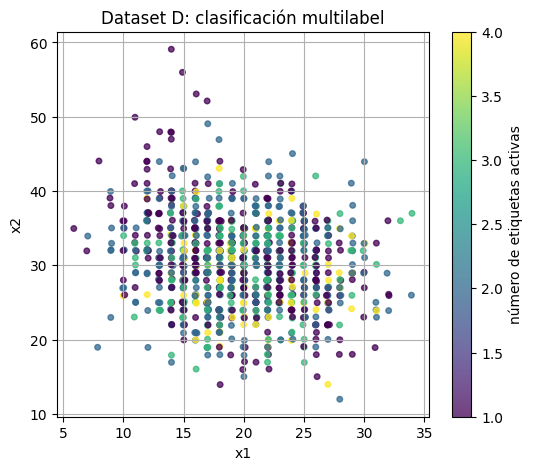

X_D_train: (1000, 2)
y_D_train: (1000, 4)


In [16]:
D_train = pd.read_csv(DATA_DIR / "dataset_D_train.csv")
D_dev = pd.read_csv(DATA_DIR / "dataset_D_dev.csv")

# Non-graded: visualización.
# Para visualizar multilabel en 2D, coloreamos por el número de etiquetas activas.
label_cols = ["y0", "y1", "y2", "y3"]
D_train["label_count"] = D_train[label_cols].sum(axis=1)

plt.figure(figsize=(6, 5))
plt.scatter(D_train["x1"], D_train["x2"], c=D_train["label_count"], s=16, alpha=0.75)
plt.title("Dataset D: clasificación multilabel")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="número de etiquetas activas")
plt.grid(True)
plt.show()

# Non-graded: normalización y estandarización
X_D_train, X_D_dev, norm_D, std_D = normalize_all_then_standardize_train(D_train, D_dev)
y_D_train = D_train[label_cols].to_numpy(dtype=np.float32)
y_D_dev = D_dev[label_cols].to_numpy(dtype=np.float32)

train_D_loader = DataLoader(
    TensorDataset(torch.tensor(X_D_train), torch.tensor(y_D_train)),
    batch_size=64,
    shuffle=True,
)
dev_D_loader = DataLoader(
    TensorDataset(torch.tensor(X_D_dev), torch.tensor(y_D_dev)),
    batch_size=256,
    shuffle=False,
)

print("X_D_train:", X_D_train.shape)
print("y_D_train:", y_D_train.shape)


In [17]:
# GRADED: Tarea 3

class MultilabelMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=8, output_dim=4):
        super().__init__()

        # START CODE HERE
        #raise NotImplementedError("Implemente la arquitectura 2 -> 8 -> 8 -> 4 con ReLU.")

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

        # END CODE HERE

    def forward(self, x):
        # START CODE HERE
        #raise NotImplementedError("Implemente el forward pass.")

        return self.net(x)

        # END CODE HERE


def train_multilabel_model(model, train_loader, epochs=100, lr=1e-2):
    """
    Entrena un modelo de clasificación multilabel usando BCEWithLogitsLoss.

    Debe retornar una lista con la pérdida promedio por epoch.
    """
    # START CODE HERE
    #raise NotImplementedError("Implemente el loop de entrenamiento para clasificación multilabel.")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_n = 0

        for xb, yb in train_loader:
            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_n += xb.size(0)

        history.append(total_loss / total_n)

    return history


    # END CODE HERE


def evaluate_multilabel_model(model, dev_loader, threshold=0.5):
    """
    Evalúa el modelo multilabel.

    Debe retornar un diccionario con:
        subset_accuracy, micro_f1, macro_f1
    """
    # START CODE HERE
    #raise NotImplementedError("Implemente las métricas de clasificación multilabel.")

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for xb, yb in dev_loader:
            logits = model(xb)
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).int()

            y_true.append(yb.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    return {
        "subset_accuracy": accuracy_score(y_true, y_pred),
        "micro_f1": f1_score(y_true, y_pred, average="micro",
    zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

    # END CODE HERE


In [18]:
# Public test: ejecutar después de implementar Tarea 3.
public_tests.test_tarea3(globals())


Tarea 3 public tests passed.


# Ejecución de pruebas privadas

En un ambiente real de calificación, el archivo `private.py` no se entrega al estudiante.

Las siguientes líneas deben permanecer comentadas en la versión pública. Cuando el instructor ejecute las pruebas privadas, estas líneas pueden activarse o ejecutarse desde otro script. El archivo privado escribirá un CSV llamado `notas.csv` con columnas:

- `tarea1`;
- `tarea2`;
- `tarea3`;
- `nota final`.

La nota final se calcula como:

$$
\text{nota final}
=
0.30(tarea1)
+
0.30(tarea2)
+
0.40(tarea3)
$$


# Apéndice: ejemplos computables a mano

## Forward pass de una neurona

Suponga:

$$
\mathbf{x}=
\begin{bmatrix}
2\\
-1
\end{bmatrix},
\quad
\mathbf{w}=
\begin{bmatrix}
0.5\\
-2
\end{bmatrix},
\quad
b=1
$$

Entonces:

$$
z=\mathbf{w}^T\mathbf{x}+b
$$

$$
z=(0.5)(2)+(-2)(-1)+1=4
$$

Si usamos ReLU:

$$
a=\max(0,4)=4
$$

## MSE

Si:

$$
\mathbf{y}=[3,0,1],
\quad
\hat{\mathbf{y}}=[2.5,0.7,1.2]
$$

entonces:

$$
MSE=\frac{(3-2.5)^2+(0-0.7)^2+(1-1.2)^2}{3}
$$

## BCE

Si \(y=1\) y \(\hat{p}=0.8\):

$$
BCE=-\log(0.8)
$$

Si \(y=0\) y \(\hat{p}=0.8\):

$$
BCE=-\log(1-0.8)
$$

## Categorical cross-entropy

Si la clase correcta es \(2\) y:

$$
\mathbf{p}=[0.1,0.7,0.2]
$$

entonces:

$$
CE=-\log(0.2)
$$


In [19]:
# Cálculos rápidos para verificar los ejemplos a mano.

z = 0.5 * 2 + (-2) * (-1) + 1
relu_z = max(0, z)
print("Forward neurona:", z, relu_z)

y = np.array([3.0, 0.0, 1.0])
y_hat = np.array([2.5, 0.7, 1.2])
mse = np.mean((y - y_hat) ** 2)
print("MSE:", mse)

print("BCE y=1, p=0.8:", -np.log(0.8))
print("BCE y=0, p=0.8:", -np.log(1 - 0.8))

p = np.array([0.1, 0.7, 0.2])
correct_class = 2
print("CE:", -np.log(p[correct_class]))


Forward neurona: 4.0 4.0
MSE: 0.26
BCE y=1, p=0.8: 0.2231435513142097
BCE y=0, p=0.8: 1.6094379124341005
CE: 1.6094379124341003
